In [1]:
import numpy as np
import openturns as ot
import openturns.viewer as otw
import otcalibration as otc

In [2]:
import matplotlib

matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.size"] = "10"

In [3]:
ot.RandomGenerator.SetSeed(0)

In [4]:
size = 10
inputObservations = ot.Sample([[0.5 + i] for i in range(size)])
inputObservations.asPoint()

class=Point name=Unnamed dimension=10 values=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5]

La fonction est :
$$
g(x) = a + \exp(b x), 
$$
pour tout $x\in[0.5,9.5]$.

In [5]:
inVars = ["a", "b", "x"]
formulas = ["a + exp(b * x)"]
g = ot.SymbolicFunction(inVars, formulas)
g

class=SymbolicFunction name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)]

In [6]:
p_ref = [2.8, 0.5]
params = [0, 1]
model = ot.ParametricFunction(g, params, p_ref)
model.setOutputDescription(["y"])
model

class=FunctionImplementation name=Unnamed description=[x,y] evaluationImplementation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] parameters positions=[0,1] parameters=class=PointWithDescription name=Unnamed dimension=2 description=[a,b] values=[2.8,0.5] input positions=[2] gradientImplementation=class=ParametricGradient evaluation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] parameters positions=[0,1] parameters=class=PointWithDescription name=Unnamed dimension=2 description=[a,b] values=[2.8,0.5] input positions=[2] hessianImplementation=class=ParametricHessian evaluation=class=ParametricEvaluation function=class=Function name=Unnamed implementation=class=FunctionImplementation name=Unnamed description=[a,b,x,y0] evaluationImplementation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] gradientImplementation=class=SymbolicGradient name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] hessianImplementation=class=SymbolicHessian name=Unnamed evaluation=class=SymbolicEvaluation name=Unnamed inputVariablesNames=[a,b,x] outputVariablesNames=[y0] formulas=[a + exp(b * x)] parameters positions=[0,1] parameters=class=PointWithDescription name=Unnamed dimension=2 description=[a,b] values=[2.8,0.5] input positions=[2]

In [7]:
sigmaNoiseObservation = 5.0
observationOutputNoise = ot.Normal(0.0, sigmaNoiseObservation)
observationOutputNoise

class=Normal name=Normal dimension=1 mean=class=Point name=Unnamed dimension=1 values=[0] sigma=class=Point name=Unnamed dimension=1 values=[5] correlationMatrix=class=CorrelationMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[1]

In [8]:
if True:
    outputObservations = ot.Sample(size, 1)
    outputObservations[0, 0] = 7.125
    outputObservations[1, 0] = -1.414
    outputObservations[2, 0] = 4.099
    outputObservations[3, 0] = 14.58
    outputObservations[4, 0] = 1.381
    outputObservations[5, 0] = 20.19
    outputObservations[6, 0] = 26.82
    outputObservations[7, 0] = 52.52
    outputObservations[8, 0] = 76.96
    outputObservations[9, 0] = 122.4
if False:
    outputModel = model(inputObservations)
    observationErrorSample = observationOutputNoise.getSample(size)
    outputObservations = outputModel + observationErrorSample
    print(outputObservations.asPoint())

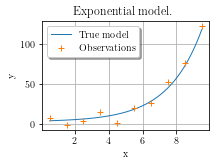

In [9]:
graph = model.draw(0.5, 9.5)
graph.setLegends(["True model"])
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Observations")
graph.add(cloud)
graph.setLegendPosition("topleft")
graph.setColors(ot.Drawable_BuildDefaultPalette(2))
graph.setTitle("Exponential model.")
#
view = otw.View(graph, figure_kw={"figsize": (3.0, 2.0)})
view.save("exp_observations.pdf")

In [10]:
candidate = ot.Point([5.0, 0.7])
candidate

class=Point name=Unnamed dimension=2 values=[5,0.7]

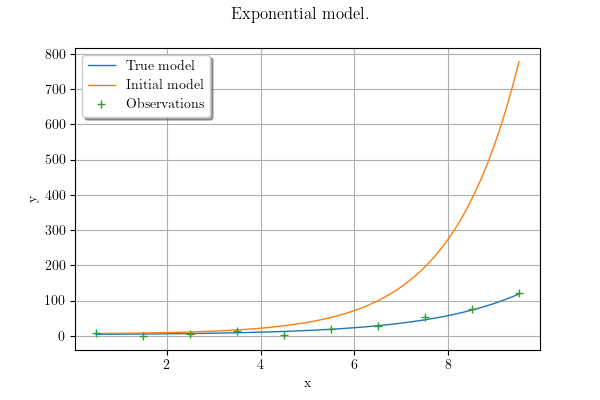

In [11]:
model.setParameter(p_ref)
graph = model.draw(0.5, 9.5)
graph.setLegends(["True model"])
#
model.setParameter(candidate)
curve = model.draw(0.5, 9.5)
curve.setLegends(["Initial model"])
graph.add(curve)
#
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Observations")
graph.add(cloud)
#
graph.setLegendPosition("topleft")
graph.setColors(ot.Drawable_BuildDefaultPalette(3))
graph.setTitle("Exponential model.")
graph

In [12]:
sigma_a = 1.0
sigma_b = 10.0
parameterCovariance = ot.CovarianceMatrix([[sigma_a ** 2, 0.0], [0.0, sigma_b ** 2]])
parameterCovariance

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[1,0,0,100]

In [13]:
p = candidate.getSize()

In [14]:
np.linalg.cond(parameterCovariance)

100.0

In [15]:
errorCovariance = ot.CovarianceMatrix([[3.0]])
errorCovariance

class=CovarianceMatrix dimension=1 implementation=class=MatrixImplementation name=Unnamed rows=1 columns=1 values=[3]

In [16]:
np.linalg.cond(errorCovariance)

1.0

In [17]:
algo = ot.GaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
    "SVD",
)
algo.run()
calibrationResult = algo.getResult()

## Analysis of the results

The `getParameterMAP` method returns the maximum of the posterior distribution of $\theta$.

In [18]:
thetaStar = calibrationResult.getParameterMAP()
thetaStar

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

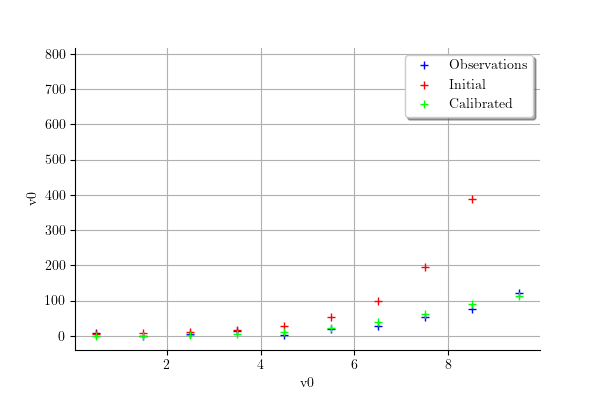

In [19]:
calibrationResult.drawObservationsVsInputs()

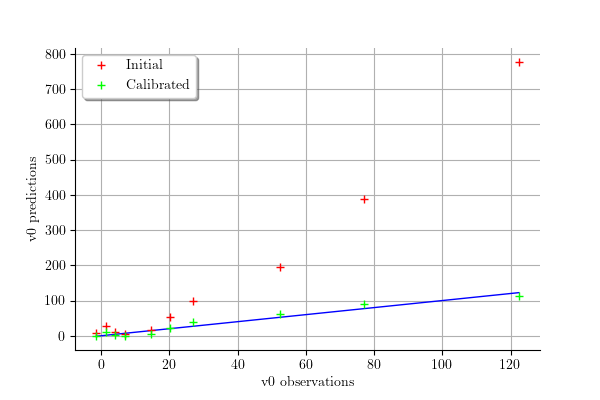

In [20]:
calibrationResult.drawObservationsVsPredictions()

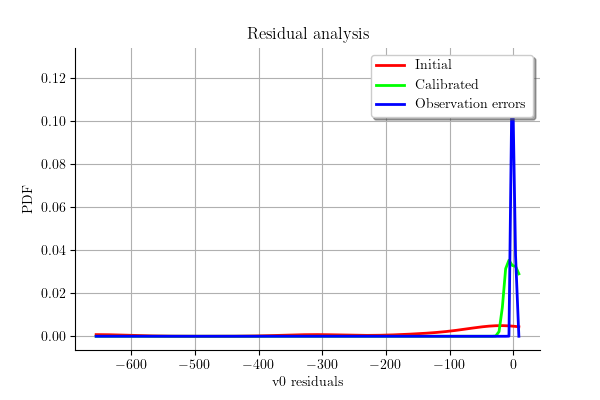

In [21]:
calibrationResult.drawResiduals()

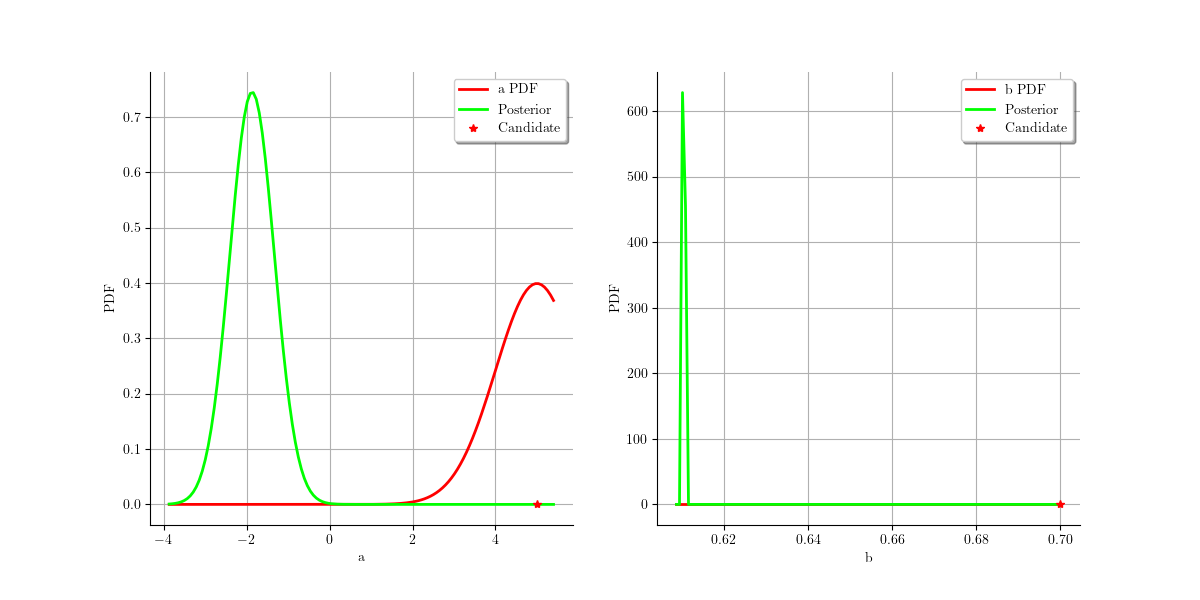

In [22]:
calibrationResult.drawParameterDistributions()

In [23]:
thetaPosterior = calibrationResult.getParameterPosterior()

# See Ticket 1106 on github
ot.ResourceMap.SetAsUnsignedInteger("Normal-SmallDimension", 1)
thetaPosterior.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]

class=Interval name=Unnamed dimension=2 lower bound=class=Point name=Unnamed dimension=2 values=[-3.05774,0.609985] upper bound=class=Point name=Unnamed dimension=2 values=[-0.67785,0.611033] finite lower bound=[1,1] finite upper bound=[1,1]

In [24]:
covarianceThetaStar = thetaPosterior.getCovariance()
covarianceThetaStar

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.287044,-5.59683e-05,-5.59683e-05,5.56637e-08]

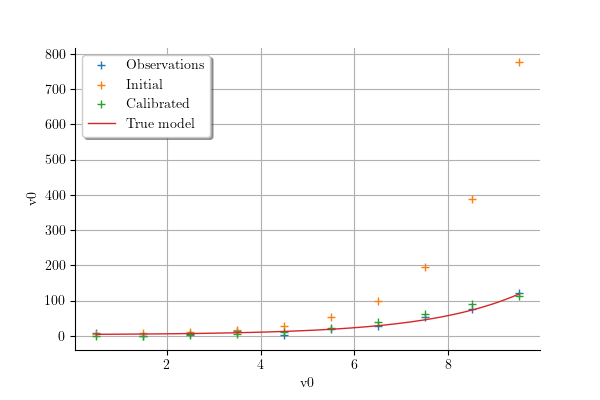

In [25]:
grid = calibrationResult.drawObservationsVsInputs()
grid.setLegendPosition("topleft")
graph = grid.getGraph(0, 0)
model.setParameter(p_ref)
curve = model.draw(0.5, 9.5)
curve.setLegends(["True model"])
graph.add(curve)
graph.setColors(ot.Drawable_BuildDefaultPalette(4))
grid.setGraph(0, 0, graph)
grid

## Calculs génériques

In [26]:
parameterDimension = candidate.getDimension()

In [27]:
model.setParameter(candidate)
modelObservations = model(inputObservations)
modelObservations[0:5]

class=Sample name=Unnamed implementation=class=SampleImplementation name=Unnamed size=5 dimension=1 description=[y0] data=[[6.41907],[7.85765],[10.7546],[16.5883],[28.3361]]

In [28]:
outputDimension = modelObservations.getDimension()
outputDimension

1

In [29]:
gradientObservations = otc.computeJacobianParameterMatrix(model, inputObservations)
gradientObservations

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=2 values=[1,1,1,1,1,1,1,1,1,1,0.709534,4.28648,14.3865,40.5592,105.012,258.462,615.111,1429.25,3261.9,7341.45]

In [30]:
np.log10(np.linalg.cond(gradientObservations))

3.4770416032507496

In [31]:
residuals = outputObservations - modelObservations
# Stack the residuals by observation,
#   deltay = [residuals[i,0],residuals[i,1],...,residuals[i,outputDimension]]
deltay = ot.Point(size * outputDimension)
for i in range(size):
    for j in range(outputDimension):
        deltay[i * outputDimension + j] = residuals[i, j]
deltay

class=Point name=Unnamed dimension=10 values=[0.705932,-9.27165,-6.6556,-2.00835,-26.9551,-31.8031,-72.8124,-143.046,-311.793,-655.384]

In [32]:
observationDimension = errorCovariance.getDimension()
observationDimension

1

In [33]:
R = otc.computeGlobalObservationsCovarianceMatrixFromLocalCovariance(
    deltay.getSize(), errorCovariance
)
R

class=CovarianceMatrix dimension=10 implementation=class=MatrixImplementation name=Unnamed rows=10 columns=10 values=[3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3]

## Par résolution d'un problème de moindres carrés linéaires

Calcule le facteur de Cholesky $L_B$ de $B$ tel que : 
$$
B = L_B L_B^T
$$
où $L_B$ est une matrice triangulaire inférieure.

In [34]:
B = ot.CovarianceMatrix(parameterCovariance)
LB = B.computeCholesky()
LB

class=TriangularMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[1,0,0,10]

Calcule le facteur de Cholesky $L_R$ de $R$ tel que : 
$$
R = L_R L_R^T
$$
où $L_R$ est une matrice triangulaire inférieure.

In [35]:
LR = R.computeCholesky()
LR[0:5, :]

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=5 columns=10 values=[1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,1.73205,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]

Calcule $L_B^{-1}$, première partie de la matrice de conception étendue.

In [36]:
ILB = ot.IdentityMatrix(parameterDimension)
invLB = LB.solveLinearSystem(ILB)
invLB

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[1,0,0,0.1]

Calcule $L_R^{-1}J$, seconde partie de la matrice de conception étendue.

In [37]:
invLRJ = LR.solveLinearSystem(gradientObservations)
invLRJ

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=10 columns=2 values=[0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.57735,0.40965,2.4748,8.30605,23.4169,60.6289,149.223,355.134,825.176,1883.26,4238.59]

Crée $\bar{A}$, la matrice de conception étendue du problème de moindres carrés linéaires.

In [38]:
Abar = ot.Matrix(parameterDimension + size * outputDimension, parameterDimension)
Abar[0:parameterDimension, 0:parameterDimension] = invLB
for i in range(size):
    for j in range(outputDimension):
        for k in range(parameterDimension):
            Abar[i * outputDimension + j + parameterDimension, k] = -invLRJ[
                i * outputDimension + j, k
            ]
Abar

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=12 columns=2 values=[1,0,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,-0.57735,0,0.1,-0.40965,-2.4748,-8.30605,-23.4169,-60.6289,-149.223,-355.134,-825.176,-1883.26,-4238.59]

In [39]:
np.log10(np.linalg.cond(Abar))

3.403573053167151

Calcule $L_R^{-1} (y - H(\mu))$, second membre du résidu étendu.

In [40]:
invLRz = LR.solveLinearSystem(deltay)
invLRz

class=Point name=Unnamed dimension=10 values=[0.40757,-5.35299,-3.84261,-1.15952,-15.5625,-18.3615,-42.0383,-82.5878,-180.014,-378.386]

Créée $\bar{y}$ le second membre du problème de moindres carrés linéaires étendu.

In [41]:
ybar = ot.Point(parameterDimension + size * outputDimension)
for i in range(size):
    for j in range(outputDimension):
        ybar[i * outputDimension + j + parameterDimension] = -invLRz[
            i * outputDimension + j
        ]
ybar

class=Point name=Unnamed dimension=12 values=[0,0,-0.40757,5.35299,3.84261,1.15952,15.5625,18.3615,42.0383,82.5878,180.014,378.386]

In [42]:
method = ot.SVDMethod(Abar)
method

class=SVDMethod

In [43]:
deltaTheta = method.solve(ybar)
deltaTheta

class=Point name=Unnamed dimension=2 values=[-6.86779,-0.0894906]

In [44]:
thetaStarLLSQ = candidate + deltaTheta
thetaStarLLSQ

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [45]:
covarianceThetaLLSQ = method.getGramInverse()
covarianceThetaLLSQ

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.287044,-5.59683e-05,-5.59683e-05,5.56637e-08]

In [46]:
np.log10(np.linalg.cond(covarianceThetaLLSQ))

6.807146106334302

In [47]:
disttheta = ot.Normal(thetaStarLLSQ, covarianceThetaLLSQ)

In [48]:
ot.ResourceMap.SetAsUnsignedInteger("Normal-SmallDimension", 1)
disttheta.computeBilateralConfidenceIntervalWithMarginalProbability(0.95)[0]

class=Interval name=Unnamed dimension=2 lower bound=class=Point name=Unnamed dimension=2 values=[-3.0555,0.609986] upper bound=class=Point name=Unnamed dimension=2 values=[-0.680089,0.611032] finite lower bound=[1,1] finite upper bound=[1,1]

## Calibration based on Kalman matrix

Compute inverses of B and R.

In [49]:
B = ot.CovarianceMatrix(parameterCovariance)
IB = ot.IdentityMatrix(parameterDimension)
invB = B.solveLinearSystem(IB)

In [50]:
IR = ot.IdentityMatrix(R.getNbRows())
invR = R.solveLinearSystem(IR)

Calcule $A^{-1} = B^{-1} + J^T R^{-1} J = B^{-1} + J^T (J^T R^{-1})^T$.

Soit $C =J^T R^{-1}$. 

Cela implique $A^{-1} = B^{-1} + J^T C^T$.

In [51]:
C = gradientObservations.transpose() * invR

In [52]:
invA = invB + C * gradientObservations
invA

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[4.33333,4357.04,4357.04,2.23459e+07]

In [53]:
np.log10(np.linalg.cond(invA))

6.807146106334149

In [54]:
invB

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[1,0,0,0.01]

In [55]:
C * gradientObservations

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[3.33333,4357.04,4357.04,2.23459e+07]

Calcule $K = A J^T R^{-1}$ en tant que solution de l'équation matricielle $A^{-1}K = C$.

In [56]:
K = invA.solveLinearSystem(C)
K

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=10 values=[0.095668,-1.86429e-05,0.0956013,-1.85766e-05,0.0954128,-1.83892e-05,0.0949246,-1.79035e-05,0.0937221,-1.67076e-05,0.0908594,-1.38604e-05,0.0842057,-7.24298e-06,0.0690171,7.86297e-06,0.0348269,4.18671e-05,-0.0412815,0.000117561]

In [57]:
np.log10(np.linalg.cond(K))

3.330104503083655

Calcule $\hat{\theta} = \mu  + K (y - H(\mu ))$.

In [58]:
thetaStarKalman = candidate + K * deltay
thetaStarKalman

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [59]:
L = IB - K * gradientObservations

In [60]:
covarianceThetaStarKalman = K * R * K.transpose() + L * B * L.transpose()
covarianceThetaStarKalman

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.287044,-5.59683e-05,-5.59683e-05,5.56637e-08]

In [61]:
np.log10(np.linalg.cond(covarianceThetaStarKalman))

6.807146106334302

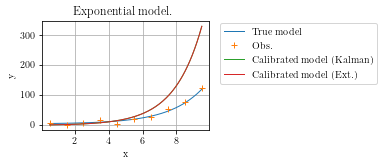

In [62]:
# 1. True model
model.setParameter(p_ref)
graph = model.draw(0.5, 9.5)
graph.setLegends(["True model"])
# 2. Obs
cloud = ot.Cloud(inputObservations, outputObservations)
cloud.setLegend("Obs.")
graph.add(cloud)
# 3. Calibrated model
model.setParameter(thetaStarKalman)
curve = model.draw(0.5, 9.5)
curve.setLegends(["Calibrated model (Kalman)"])
graph.add(curve)
# 4.
model.setParameter(thetaStar)
curve = model.draw(0.5, 9.5)
curve.setLegends(["Calibrated model (Ext.)"])
graph.add(curve)
#
graph.setLegendPosition("topleft")
graph.setColors(ot.Drawable_BuildDefaultPalette(4))
# Prepare figure
graph.setTitle("Exponential model.")
legends = graph.getLegends()
graph.setLegendPosition("")
view = otw.View(graph, figure_kw={"figsize": (3.0, 2.0)})
figure = view.getFigure()
figure.legend(legends, bbox_to_anchor=(1.7, 0.9))
figure.savefig("exp_fit.pdf")

## Vérification de la fonction coût

L'objectif est de vérifier laquelle des deux solutions minimise la fonction coût.

Avant calage.

In [63]:
otc.gaussianCalibrationCostFunction(
    candidate,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[92396.73081011313, 0.0, 92396.73081011313]

Calage par la matrice de Kalman.

In [64]:
thetaStarKalman

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [65]:
otc.gaussianCalibrationCostFunction(
    thetaStarKalman,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[137.36797718953756, 23.58334032987293, 113.78463685966462]

Calage par décomposition de Cholesky.

In [66]:
thetaStarLLSQ

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [67]:
otc.gaussianCalibrationCostFunction(
    thetaStarLLSQ,
    candidate,
    parameterCovariance,
    modelObservations,
    gradientObservations,
    outputObservations,
    R,
)

[137.36797718953773, 23.583340330961715, 113.78463685857601]

## Validation

In [68]:
def computeGaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
):
    """Use GaussianLinearCalibration"""
    algo = ot.GaussianLinearCalibration(
        model,
        inputObservations,
        outputObservations,
        candidate,
        parameterCovariance,
        errorCovariance,
    )
    algo.run()
    calibrationResult = algo.getResult()
    thetaStar = calibrationResult.getParameterMAP()
    thetaPosterior = calibrationResult.getParameterPosterior()
    covarianceThetaStar = thetaPosterior.getCovariance()
    return thetaStar, covarianceThetaStar

## GaussianLinearCalibrationCompute

In [69]:
thetaStar, covarianceThetaStar = computeGaussianLinearCalibration(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)

In [70]:
thetaStar

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [71]:
covarianceThetaStar

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.287044,-5.59683e-05,-5.59683e-05,5.56637e-08]

## Kalman

In [72]:
thetaStar, covarianceThetaStar = otc.gaussianLinearCalibrationFromKalman(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
thetaStar

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [73]:
covarianceThetaStar

class=Matrix implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.287044,-5.59683e-05,-5.59683e-05,5.56637e-08]

## From the extended linear least squares

In [74]:
thetaStar, covarianceThetaStar = otc.gaussianLinearCalibrationFromCholesky(
    model,
    inputObservations,
    outputObservations,
    candidate,
    parameterCovariance,
    errorCovariance,
)
thetaStar

class=Point name=Unnamed dimension=2 values=[-1.86779,0.610509]

In [75]:
covarianceThetaStar

class=CovarianceMatrix dimension=2 implementation=class=MatrixImplementation name=Unnamed rows=2 columns=2 values=[0.287044,-5.59683e-05,-5.59683e-05,5.56637e-08]